In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df=pd.read_csv("/content/house_data.csv",engine='python',on_bad_lines='skip')

In [58]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [59]:
df.shape

(21613, 21)

In [60]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.drop_duplicates(inplace=True)

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.drop(['id', 'date'], inplace=True, axis=1, errors='ignore')
X = df.drop('price', axis=1)
y = df['price']

In [65]:
df.head(3)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062


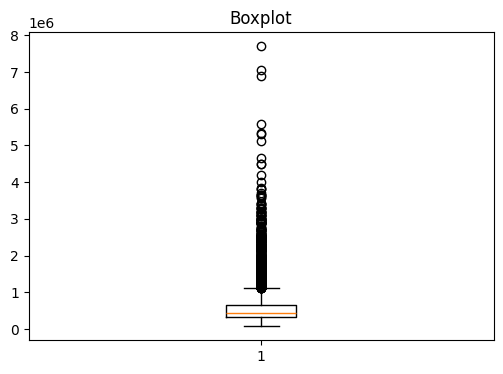

In [66]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.boxplot(df['price'])
plt.title('Boxplot')
plt.show()

In [67]:

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {count}")

price: 1146
bedrooms: 546
bathrooms: 571
sqft_living: 572
sqft_lot: 2425
floors: 0
waterfront: 163
view: 2124
condition: 30
grade: 1911
sqft_above: 611
sqft_basement: 496
yr_built: 0
yr_renovated: 914
zipcode: 0
lat: 2
long: 256
sqft_living15: 544
sqft_lot15: 2194


In [68]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print(len(outliers))

1146


In [69]:

total_rows = len(df)
outlier_rows = len(outliers)
print("Total rows:", total_rows)
print("Outlier rows:", outlier_rows)
print("Percentage:", (outlier_rows / total_rows) * 100)

Total rows: 21613
Outlier rows: 1146
Percentage: 5.302364317771711


In [70]:
df['price'].describe()

,price
count,2.161300e+04
mean,5.400881e+05
std,3.671272e+05
min,7.500000e+04
25%,3.219500e+05
50%,4.500000e+05
75%,6.450000e+05
max,7.700000e+06


In [71]:
print('Outliers based on IQR method for price:')
display(outliers.head())

Outliers based on IQR method for price:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
5,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
21,2000000.0,3,2.75,3050,44867,1.0,0,4,3,9,2330,720,1968,0,98040,47.5316,-122.233,4110,20336
49,1350000.0,3,2.50,2753,65005,1.0,1,2,5,9,2165,588,1953,0,98070,47.4041,-122.451,2680,72513
69,1325000.0,5,2.25,3200,20158,1.0,0,0,3,8,1600,1600,1965,0,98004,47.6303,-122.215,3390,20158
125,1450000.0,4,2.75,2750,17789,1.5,0,0,3,8,1980,770,1914,1992,98004,47.6141,-122.212,3060,11275


In [72]:
print('\nDescriptive statistics for outlier prices:')
display(outliers['price'].describe())


Descriptive statistics for outlier prices:


,price
count,1.146000e+03
mean,1.667087e+06
std,6.523358e+05
min,1.130000e+06
25%,1.260125e+06
50%,1.450000e+06
75%,1.813750e+06
max,7.700000e+06


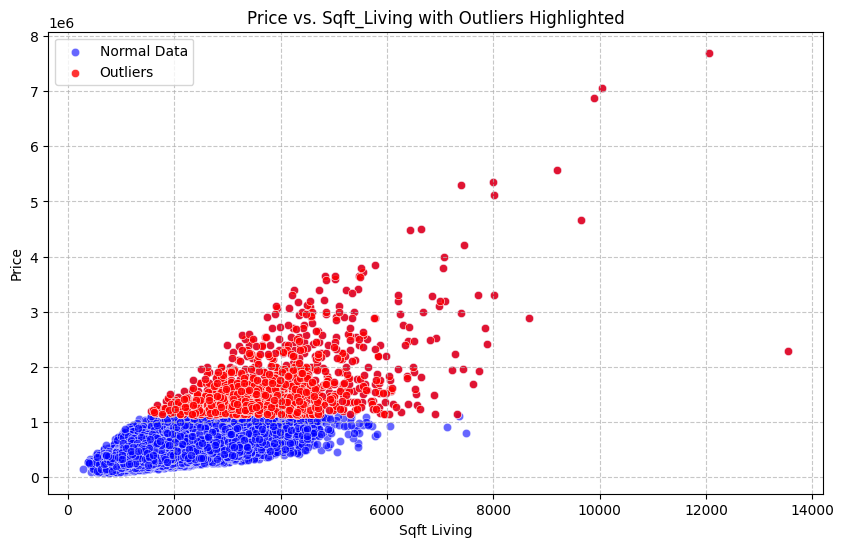

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sqft_living', y='price', color='blue', alpha=0.6, label='Normal Data')
sns.scatterplot(data=outliers, x='sqft_living', y='price', color='red', alpha=0.8, label='Outliers')
plt.title('Price vs. Sqft_Living with Outliers Highlighted')
plt.xlabel('Sqft Living')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [74]:
display(outliers)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
5,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
21,2000000.0,3,2.75,3050,44867,1.0,0,4,3,9,2330,720,1968,0,98040,47.5316,-122.233,4110,20336
49,1350000.0,3,2.50,2753,65005,1.0,1,2,5,9,2165,588,1953,0,98070,47.4041,-122.451,2680,72513
69,1325000.0,5,2.25,3200,20158,1.0,0,0,3,8,1600,1600,1965,0,98004,47.6303,-122.215,3390,20158
125,1450000.0,4,2.75,2750,17789,1.5,0,0,3,8,1980,770,1914,1992,98004,47.6141,-122.212,3060,11275
153,2250000.0,4,3.25,5180,19850,2.0,0,3,3,12,3540,1640,2006,0,98006,47.5620,-122.162,3160,9750
216,1505000.0,5,3.00,3300,33474,1.0,0,3,3,9,1870,1430,1957,1991,98040,47.5673,-122.210,3836,20953
246,2400000.0,4,2.50,3650,8354,1.0,1,4,3,9,1830,1820,2000,0,98074,47.6338,-122.072,3120,18841
269,2900000.0,4,3.25,5050,20100,1.5,0,2,3,11,4750,300,1982,2008,98004,47.6312,-122.223,3890,20060
270,1365000.0,4,4.75,5310,57346,2.0,0,0,4,11,5310,0,1989,0,98077,47.7285,-122.042,4180,47443


In [75]:
print('Descriptive statistics for all columns in the outliers DataFrame:')
display(outliers.describe())

Descriptive statistics for all columns in the outliers DataFrame:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,1.146000e+03,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000
mean,1.667087e+06,4.104712,3.242147,3943.389180,23975.275742,1.820681,0.089005,1.335079,3.464223,9.912740,3218.218150,725.171030,1974.472077,258.016579,98066.938918,47.616567,-122.225166,3134.870855,18507.986911
std,6.523358e+05,0.928649,0.890846,1233.067707,59535.470266,0.485960,0.284876,1.568614,0.708669,1.182579,1152.299771,712.649108,32.765271,670.317202,55.302390,0.058931,0.108148,845.057150,38054.596107
min,1.130000e+06,0.000000,0.000000,1560.000000,609.000000,1.000000,0.000000,0.000000,1.000000,6.000000,1040.000000,0.000000,1900.000000,0.000000,98004.000000,47.329300,-122.451000,1100.000000,1224.000000
25%,1.260125e+06,4.000000,2.500000,3120.000000,7226.750000,1.500000,0.000000,0.000000,3.000000,9.000000,2352.500000,0.000000,1951.000000,0.000000,98008.000000,47.575850,-122.289000,2552.500000,6854.000000
50%,1.450000e+06,4.000000,3.250000,3790.000000,11495.500000,2.000000,0.000000,0.000000,3.000000,10.000000,3060.000000,700.000000,1985.000000,0.000000,98040.000000,47.626300,-122.225000,3055.000000,11056.500000
75%,1.813750e+06,5.000000,3.750000,4487.500000,19438.250000,2.000000,0.000000,3.000000,4.000000,11.000000,3920.000000,1200.000000,2003.000000,0.000000,98112.000000,47.648150,-122.183000,3717.500000,17592.250000
max,7.700000e+06,10.000000,8.000000,13540.000000,920423.000000,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.773500,-121.756000,6210.000000,858132.000000


In [76]:
# Identify potentially invalid outliers based on specific rules
potentially_invalid_outliers = outliers[
    (outliers['bedrooms'] > 10) |
    (outliers['bathrooms'] > 8)
    # Add more rules as needed, e.g., | (outliers['sqft_living'] < 500)
]

print('Potentially invalid outliers (e.g., too many bedrooms/bathrooms):')
display(potentially_invalid_outliers)

print(f'Number of potentially invalid outliers flagged: {len(potentially_invalid_outliers)}')

# The remaining outliers can be considered 'valid' but extreme
valid_outliers = outliers.drop(potentially_invalid_outliers.index)
print(f'Number of valid (extreme but plausible) outliers: {len(valid_outliers)}')


Potentially invalid outliers (e.g., too many bedrooms/bathrooms):


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15


Number of potentially invalid outliers flagged: 0
Number of valid (extreme but plausible) outliers: 1146


In [77]:
total_rows = len(df)
outlier_rows = len(outliers)

print("Total rows:", total_rows)
print("Outlier rows:", outlier_rows)
print("Percentage:", (outlier_rows / total_rows) * 100)

Total rows: 21613
Outlier rows: 1146
Percentage: 5.302364317771711


In [78]:
corr_matrix = df.corr(numeric_only=True)

high_corr = (
    corr_matrix.where(abs(corr_matrix) > 0.8)
    .stack()
    .reset_index()
)
print(corr_matrix)

                  price  bedrooms  bathrooms  sqft_living  sqft_lot    floors  \
price          1.000000  0.308350   0.525138     0.702035  0.089661  0.256794   
bedrooms       0.308350  1.000000   0.515884     0.576671  0.031703  0.175429   
bathrooms      0.525138  0.515884   1.000000     0.754665  0.087740  0.500653   
sqft_living    0.702035  0.576671   0.754665     1.000000  0.172826  0.353949   
sqft_lot       0.089661  0.031703   0.087740     0.172826  1.000000 -0.005201   
floors         0.256794  0.175429   0.500653     0.353949 -0.005201  1.000000   
waterfront     0.266369 -0.006582   0.063744     0.103818  0.021604  0.023698   
view           0.397293  0.079532   0.187737     0.284611  0.074710  0.029444   
condition      0.036362  0.028472  -0.124982    -0.058753 -0.008958 -0.263768   
grade          0.667434  0.356967   0.664983     0.762704  0.113621  0.458183   
sqft_above     0.605567  0.477600   0.685342     0.876597  0.183512  0.523885   
sqft_basement  0.323816  0.3

In [79]:
corr_matrix = df.corr(numeric_only=True)

high_corr = (
    corr_matrix.where(abs(corr_matrix) > 0.8)
    .stack()
    .reset_index()
)

high_corr.columns = ["Feature1", "Feature2", "Correlation"]

# Same feature pair remove
high_corr = high_corr[high_corr["Feature1"] != high_corr["Feature2"]]

print(high_corr)

       Feature1     Feature2  Correlation
4   sqft_living   sqft_above     0.876597
11   sqft_above  sqft_living     0.876597


In [80]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

corr = df.corr(numeric_only=True)

print(corr)

                  price  bedrooms  bathrooms  sqft_living  sqft_lot    floors  \
price          1.000000  0.308350   0.525138     0.702035  0.089661  0.256794   
bedrooms       0.308350  1.000000   0.515884     0.576671  0.031703  0.175429   
bathrooms      0.525138  0.515884   1.000000     0.754665  0.087740  0.500653   
sqft_living    0.702035  0.576671   0.754665     1.000000  0.172826  0.353949   
sqft_lot       0.089661  0.031703   0.087740     0.172826  1.000000 -0.005201   
floors         0.256794  0.175429   0.500653     0.353949 -0.005201  1.000000   
waterfront     0.266369 -0.006582   0.063744     0.103818  0.021604  0.023698   
view           0.397293  0.079532   0.187737     0.284611  0.074710  0.029444   
condition      0.036362  0.028472  -0.124982    -0.058753 -0.008958 -0.263768   
grade          0.667434  0.356967   0.664983     0.762704  0.113621  0.458183   
sqft_above     0.605567  0.477600   0.685342     0.876597  0.183512  0.523885   
sqft_basement  0.323816  0.3

In [81]:
df.corr(numeric_only=True)["price"].sort_values(ascending=False)

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
bathrooms,0.525138
view,0.397293
sqft_basement,0.323816
bedrooms,0.308350
lat,0.307003


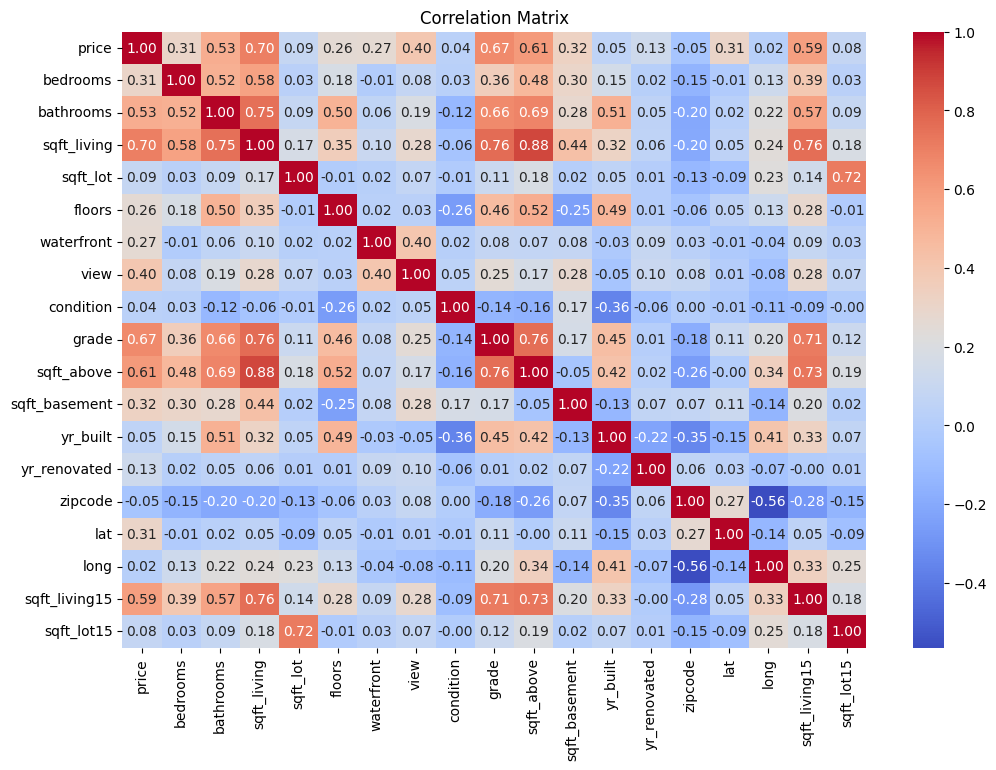

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

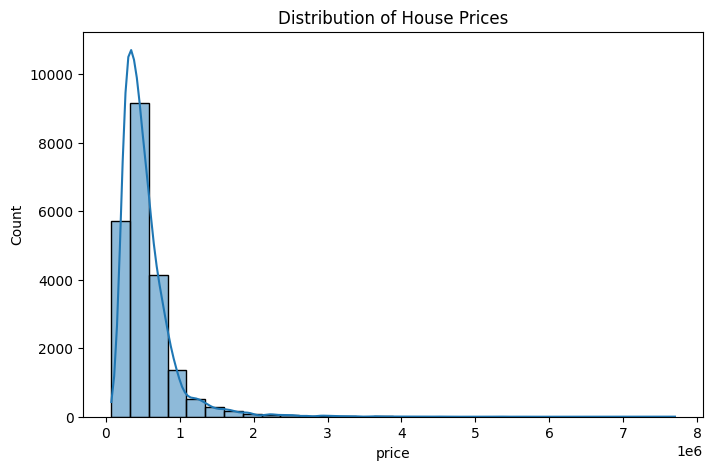

In [83]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("price")
plt.ylabel("Count")
plt.show()

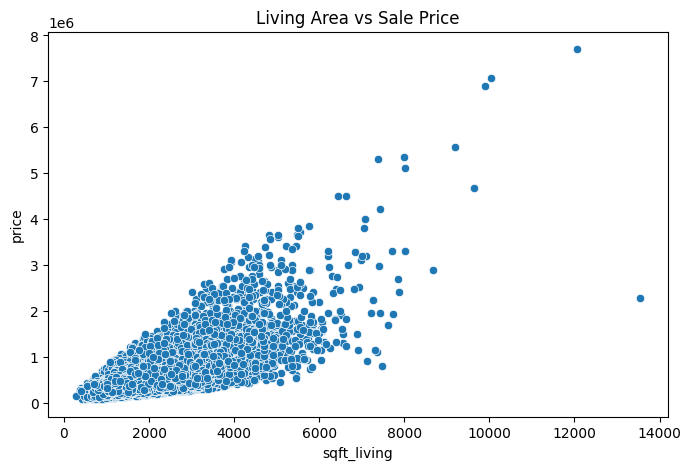

In [84]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='sqft_living', y='price')
plt.title("Living Area vs Sale Price")
plt.show()

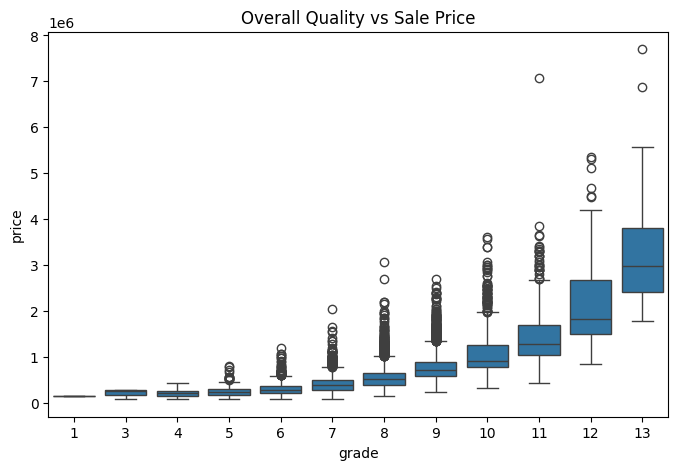

In [85]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='grade', y='price')
plt.title("Overall Quality vs Sale Price")
plt.show()

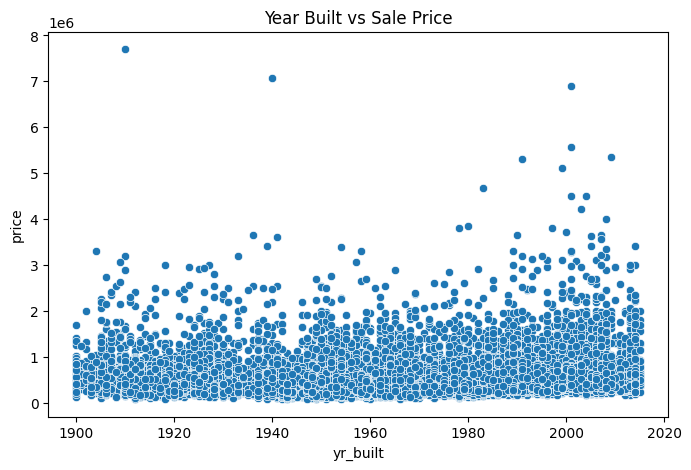

In [86]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='yr_built', y='price')
plt.title("Year Built vs Sale Price")
plt.show()

In [87]:
df['FamilyFriendlyHome'] = (
    (df['bedrooms'] >= 3) &
    (df['bathrooms'] >= 2)
).astype(int)

df['ModernHome'] = (df['yr_built'] >= 2000).astype(int)

median_area = df['sqft_living'].median()
df['SpaciousHome'] = (df['sqft_living'] > median_area).astype(int)

In [ ]:
print(df[['FamilyFriendlyHome', 'ModernHome', 'SpaciousHome']].head())

   FamilyFriendlyHome  ModernHome  SpaciousHome
0                   0           0             0
1                   1           0             1
2                   0           0             0
3                   1           0             1
4                   1           0             0


In [91]:
def family_home(row):
    if row["bedrooms"] >= 3 and row["bathrooms"] >= 2 and row["sqft_living"] >= 1800:
        return 1
    else:
        return 0

df["FamilyFriendlyHome"] = df.apply(family_home, axis=1)

In [92]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,FamilyFriendlyHome,ModernHome,SpaciousHome
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,0,0,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,1,0,1
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,0,0,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,1,0,1
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,0,0,0


In [93]:
def modern_home(row):
    if row["yr_built"] >= 2000 or row["yr_renovated"] > 0:
        return 1
    else:
        return 0

df["ModernHome"] = df.apply(modern_home, axis=1)

In [94]:
def spacious_home(area):
    if area >= 2500:
        return 2
    elif area >= 1500:
        return 1
    else:
        return 0

df["SpaciousHome"] = df["sqft_living"].apply(spacious_home)

In [95]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,FamilyFriendlyHome,ModernHome,SpaciousHome
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,0,0,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,1,1,2
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,0,0,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,1,0,1
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,0,0,1


In [96]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [100]:
model = RandomForestRegressor(n_estimators=1500, random_state=42)

# Ensure X_train and X_test are of a consistent numeric type (float32)
X_train_processed = X_train.astype('float32')
X_test_processed = X_test.astype('float32')

model.fit(X_train_processed, y_train)
y_pred = model.predict(X_test)

In [101]:
model.score(X_train,y_train)

0.9830685592516935

In [102]:
model.score(X_test,y_test)

0.8584997390152213

In [103]:
print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score : 0.8584997390152213
MAE      : 72343.33929194736
MSE      : 21391544239.166
RMSE     : 146258.48433224653


In [104]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [105]:
xgb.score(X_train, y_train)

0.9637506324255205

In [106]:
xgb.score(X_test,y_test)

0.8831830525656826

In [ ]:
print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score : 0.8831830525656826
MAE      : 68786.59448914237
MSE      : 17660002049.00214
RMSE     : 132890.94043237914


In [107]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

# Sort
importance = importance.sort_values(by="Importance", ascending=False)

# Show all features
print(importance)

          Feature  Importance
8           grade    0.395043
2     sqft_living    0.160258
5      waterfront    0.129730
14            lat    0.070218
6            view    0.043048
15           long    0.040310
11       yr_built    0.027548
16  sqft_living15    0.025788
1       bathrooms    0.024736
9      sqft_above    0.015241
13        zipcode    0.015143
12   yr_renovated    0.011164
10  sqft_basement    0.008908
7       condition    0.008757
17     sqft_lot15    0.007692
3        sqft_lot    0.007464
4          floors    0.006180
0        bedrooms    0.002772


In [108]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,FamilyFriendlyHome,ModernHome,SpaciousHome
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,0,0,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,1,1,2
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,0,0,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,1,0,1
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,0,0,1


In [109]:
ordered_columns = importance["Feature"].tolist()
# Target column-last
ordered_columns.append("price")
# Rearrange dataframe
df = df[ordered_columns]

print(df.head())

   grade  sqft_living  waterfront      lat  view     long  yr_built  \
0      7         1180           0  47.5112     0 -122.257      1955   
1      7         2570           0  47.7210     0 -122.319      1951   
2      6          770           0  47.7379     0 -122.233      1933   
3      7         1960           0  47.5208     0 -122.393      1965   
4      8         1680           0  47.6168     0 -122.045      1987   

   sqft_living15  bathrooms  sqft_above  zipcode  yr_renovated  sqft_basement  \
0           1340       1.00        1180    98178             0              0   
1           1690       2.25        2170    98125          1991            400   
2           2720       1.00         770    98028             0              0   
3           1360       3.00        1050    98136             0            910   
4           1800       2.00        1680    98074             0              0   

   condition  sqft_lot15  sqft_lot  floors  bedrooms     price  
0          3        5

In [110]:
df.head()

,grade,sqft_living,waterfront,lat,view,long,yr_built,sqft_living15,bathrooms,sqft_above,zipcode,yr_renovated,sqft_basement,condition,sqft_lot15,sqft_lot,floors,bedrooms,price
0,7,1180,0,47.5112,0,-122.257,1955,1340,1.00,1180,98178,0,0,3,5650,5650,1.0,3,221900.0
1,7,2570,0,47.7210,0,-122.319,1951,1690,2.25,2170,98125,1991,400,3,7639,7242,2.0,3,538000.0
2,6,770,0,47.7379,0,-122.233,1933,2720,1.00,770,98028,0,0,3,8062,10000,1.0,2,180000.0
3,7,1960,0,47.5208,0,-122.393,1965,1360,3.00,1050,98136,0,910,5,5000,5000,1.0,4,604000.0
4,8,1680,0,47.6168,0,-122.045,1987,1800,2.00,1680,98074,0,0,3,7503,8080,1.0,3,510000.0


In [111]:
print(df.columns.tolist())

['grade', 'sqft_living', 'waterfront', 'lat', 'view', 'long', 'yr_built', 'sqft_living15', 'bathrooms', 'sqft_above', 'zipcode', 'yr_renovated', 'sqft_basement', 'condition', 'sqft_lot15', 'sqft_lot', 'floors', 'bedrooms', 'price']


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort
importance = importance.sort_values(by="Importance", ascending=False)

# Show all features
print(importance)

In [ ]:
print(X.columns)

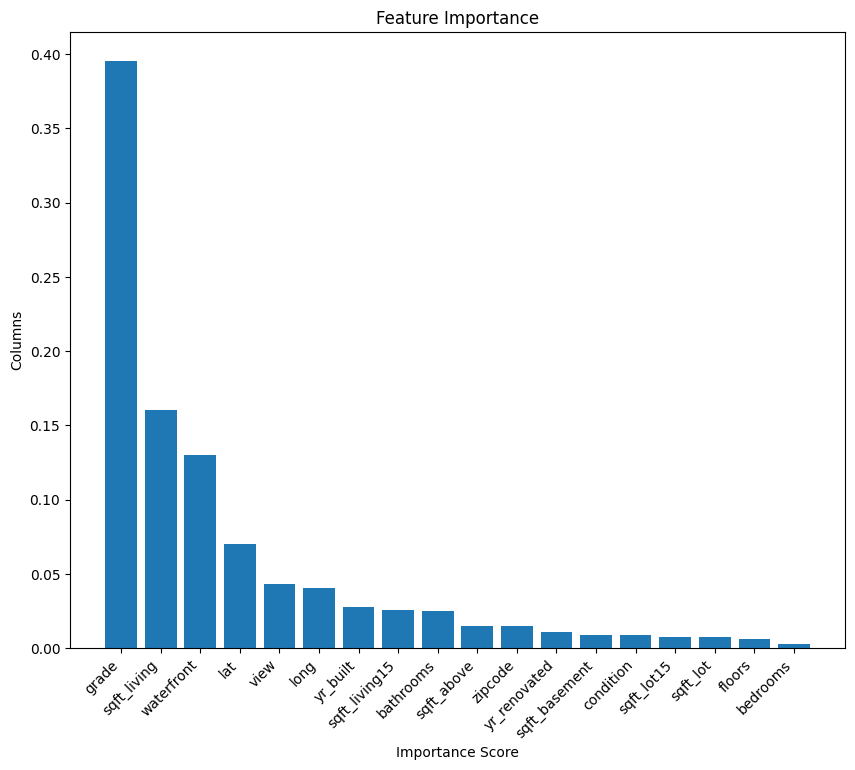

In [112]:
plt.figure(figsize=(10,8))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)
plt.xlabel("Importance Score")
plt.ylabel("Columns")
plt.title("Feature Importance")
plt.xticks(rotation=45, ha='right')
plt.show()

In [113]:
import pickle

pickle.dump(xgb, open("HouseWorth AI.pkl", "wb"))

In [114]:
!ls

 house_data.csv  'HouseWorth AI.pkl'   sample_data


In [116]:
%%writefile app.py
"""
House Price Predictor — Interactive Streamlit App
---------------------------------------------------
Light, minimalist, "architectural blueprint" themed UI (Space Grotesk + JetBrains Mono)
built with Tailwind-flavoured custom CSS/HTML injected via streamlit.components.v1.

HOW TO USE
1. Put your trained model file next to this script and update MODEL_PATH below.
   (Optionally a fitted scaler at SCALER_PATH, if you scaled numeric features.)
2. Update FEATURE_COLUMNS to EXACTLY match the column order your model was trained on.
3. streamlit run app.py
"""

import streamlit as st
import streamlit.components.v1 as components
import pandas as pd
import numpy as np
import joblib
import os
from datetime import datetime

# ============================================================
# CONFIG — edit these to match your trained model
# ============================================================
MODEL_PATH = "xgb_house_model.pkl"
SCALER_PATH = "scaler.pkl"  # optional, app skips silently if not found

# Final column order fed to model.predict(). Edit to match your training notebook exactly.
FEATURE_COLUMNS = [
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
    "waterfront", "view", "condition", "grade",
    "sqft_above", "sqft_basement", "yr_built", "yr_renovated",
    "zipcode", "lat", "long", "sqft_living15", "sqft_lot15",
    "house_age", "is_renovated", "total_rooms", "total_sqft",
    "FamilyFriendlyHome", "ModernHome", "SpaciousHome",
]

st.set_page_config(page_title="HouseWorth AI", page_icon="🏡", layout="wide")

# ============================================================
# STYLE — light, minimalist "blueprint" theme
# ============================================================
st.markdown("""
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=Inter:wght@400;500;600&family=JetBrains+Mono:wght@400;500;600&display=swap" rel="stylesheet">
<style>
:root {
  --bg:        #F6F7F4;
  --card:      #FFFFFF;
  --ink:       #1E2A24;
  --muted:     #667066;
  --pine:      #2D5B4E;
  --pine-dark: #1F4438;
  --amber:     #C9963C;
  --line:      #E4E7E1;
  --key-bg:    #FBF3E3;
}

html, body, [class*="css"] { font-family: 'Inter', sans-serif; color: var(--ink); }
.stApp { background: var(--bg); }
h1, h2, h3, .block-title { font-family: 'Space Grotesk', sans-serif !important; }
[data-testid="stNumberInput"] input, [data-testid="stTextInput"] input,
.mono-num { font-family: 'JetBrains Mono', monospace !important; }

/* header */
.hero-wrap {
  padding: 8px 4px 18px 4px;
  border-bottom: 1px solid var(--line);
  margin-bottom: 22px;
}
.eyebrow {
  font-family: 'JetBrains Mono', monospace;
  font-size: 12px; letter-spacing: 0.14em; text-transform: uppercase;
  color: var(--pine); font-weight: 600;
}
.hero-title {
  font-size: 34px; font-weight: 700; margin: 4px 0 2px 0; color: var(--ink);
}
.hero-sub { color: var(--muted); font-size: 14.5px; }

/* section card */
.section-card {
  background: var(--card);
  border: 1px solid var(--line);
  border-radius: 14px;
  padding: 20px 22px 8px 22px;
  margin-bottom: 18px;
  box-shadow: 0 1px 2px rgba(30,42,36,0.04);
}
.section-head {
  display:flex; align-items:center; gap:10px; margin-bottom: 6px;
}
.section-num {
  font-family: 'JetBrains Mono', monospace; font-size: 12px; color: var(--pine);
  background: #EAF1EE; border-radius: 6px; padding: 3px 8px; font-weight:600;
}
.section-title { font-weight: 600; font-size: 16.5px; }
.section-desc { color: var(--muted); font-size: 13px; margin-bottom: 14px; }

/* key-factor badge */
.key-badge {
  display:inline-flex; align-items:center; gap:5px;
  background: var(--key-bg); color: var(--amber); border: 1px solid #EFDCAE;
  font-family: 'JetBrains Mono', monospace; font-size: 10.5px; font-weight:600;
  letter-spacing:0.04em; text-transform:uppercase;
  padding: 2px 8px; border-radius: 999px; margin-bottom: 6px;
}
.key-badge::before { content: "●"; font-size: 8px; }

label, .stSlider label, .stSelectbox label, .stNumberInput label, .stCheckbox label {
  font-weight: 500 !important; font-size: 13.5px !important; color: var(--ink) !important;
}

/* buttons */
.stButton>button {
  background: var(--pine); color: white; border: none; border-radius: 10px;
  font-weight: 600; padding: 12px 20px; font-size: 15px;
  transition: all .15s ease; box-shadow: 0 2px 6px rgba(45,91,78,0.25);
}
.stButton>button:hover { background: var(--pine-dark); transform: translateY(-1px); box-shadow: 0 4px 10px rgba(45,91,78,0.3); }

/* toggle-like checkbox rows */
.toggle-row {
  display:flex; justify-content:space-between; align-items:center;
  border: 1px solid var(--line); border-radius: 10px; padding: 10px 14px; margin-bottom: 8px;
  background: #FBFCFA;
}
hr { border-color: var(--line); }
#MainMenu, footer, header {visibility: hidden;}
</style>
""", unsafe_allow_html=True)

# ============================================================
# HEADER
# ============================================================
st.markdown("""
<div class="hero-wrap">
  <div class="eyebrow">HOUSE PRICE PREDICTOR · XGBoost</div>
  <div class="hero-title">🏡 Enna vilai varum indha veedu?</div>
  <div class="hero-sub">Fill in the property details below — the important, price-driving factors are marked <b>Key Factor</b>. Prediction updates instantly on click.</div>
</div>
""", unsafe_allow_html=True)

# ============================================================
# HELPERS
# ============================================================
def key_badge():
    st.markdown('<div class="key-badge">Key Factor</div>', unsafe_allow_html=True)

def section_head(num, title, desc):
    st.markdown(f"""
    <div class="section-head">
      <div class="section-num">{num}</div>
      <div class="section-title">{title}</div>
    </div>
    <div class="section-desc">{desc}</div>
    """, unsafe_allow_html=True)

@st.cache_resource
def load_model():
    if os.path.exists(MODEL_PATH):
        return joblib.load(MODEL_PATH)
    return None

@st.cache_resource
def load_scaler():
    if os.path.exists(SCALER_PATH):
        return joblib.load(SCALER_PATH)
    return None

model = load_model()
scaler = load_scaler()

# ============================================================
# INPUT FORM
# ============================================================
col_main, col_side = st.columns([2, 1], gap="large")

with col_main:
    # ---- Section 1: Basic details ----
    with st.container():
        st.markdown('<div class="section-card">', unsafe_allow_html=True)
        section_head("01", "Basic Details", "Room counts and floor layout.")
        b1, b2, b3 = st.columns(3)
        with b1:
            bedrooms = st.number_input("Bedrooms", 0, 15, 3, step=1)
        with b2:
            bathrooms = st.number_input("Bathrooms", 0.0, 10.0, 2.0, step=0.25)
        with b3:
            floors = st.number_input("Floors", 1.0, 4.0, 1.0, step=0.5)
        st.markdown('</div>', unsafe_allow_html=True)

    # ---- Section 2: Size ----
    with st.container():
        st.markdown('<div class="section-card">', unsafe_allow_html=True)
        section_head("02", "Size & Layout", "Living space is the single strongest price driver.")
        key_badge()
        sqft_living = st.slider("Living area (sqft)", 300, 12000, 1800, step=50)
        s1, s2 = st.columns(2)
        with s1:
            sqft_above = st.number_input("Sqft above ground", 0, 10000, int(sqft_living * 0.8), step=50)
        with s2:
            sqft_basement = st.number_input("Sqft basement", 0, 6000, max(0, sqft_living - int(sqft_living*0.8)), step=50)
        s3, s4 = st.columns(2)
        with s3:
            sqft_lot = st.number_input("Lot size (sqft)", 300, 200000, 5000, step=100)
        with s4:
            sqft_living15 = st.number_input("Neighbours' avg living sqft", 300, 12000, 1800, step=50)
        sqft_lot15 = st.number_input("Neighbours' avg lot sqft", 300, 200000, 5000, step=100)
        st.markdown('</div>', unsafe_allow_html=True)

    # ---- Section 3: Quality & Condition ----
    with st.container():
        st.markdown('<div class="section-card">', unsafe_allow_html=True)
        section_head("03", "Quality & Condition", "Construction grade moves valuation more than most people expect.")
        q1, q2 = st.columns(2)
        with q1:
            key_badge()
            grade = st.slider("Construction grade (1 = low, 13 = luxury)", 1, 13, 7)
        with q2:
            condition = st.slider("Condition (1 = poor, 5 = excellent)", 1, 5, 3)
        y1, y2 = st.columns(2)
        with y1:
            yr_built = st.number_input("Year built", 1900, datetime.now().year, 2005, step=1)
        with y2:
            yr_renovated = st.number_input("Year renovated (0 = never)", 0, datetime.now().year, 0, step=1)
        st.markdown('</div>', unsafe_allow_html=True)

    # ---- Section 4: Location & special features ----
    with st.container():
        st.markdown('<div class="section-card">', unsafe_allow_html=True)
        section_head("04", "Location & Views", "Waterfront and view rating are rare but high-impact factors.")
        l1, l2, l3 = st.columns(3)
        with l1:
            zipcode = st.number_input("Zipcode", 90000, 99999, 98103, step=1)
        with l2:
            lat = st.number_input("Latitude", 47.0, 48.0, 47.55, step=0.001, format="%.4f")
        with l3:
            long = st.number_input("Longitude", -123.0, -121.0, -122.25, step=0.001, format="%.4f")
        f1, f2 = st.columns(2)
        with f1:
            key_badge()
            waterfront = st.selectbox("Waterfront property?", ["No", "Yes"])
        with f2:
            key_badge()
            view = st.slider("View rating (0–4)", 0, 4, 0)
        st.markdown('</div>', unsafe_allow_html=True)

    # ---- Section 5: Home style flags ----
    with st.container():
        st.markdown('<div class="section-card">', unsafe_allow_html=True)
        section_head("05", "Home Style", "Auto-suggested from your inputs above — toggle to override.")
        auto_family = bedrooms >= 3 and condition >= 3
        auto_modern = yr_built >= 2005 or yr_renovated > 0
        auto_spacious = sqft_living >= 2200

        t1, t2, t3 = st.columns(3)
        with t1:
            family_friendly = st.checkbox("👨‍👩‍👧 Family Friendly Home", value=auto_family)
        with t2:
            modern_home = st.checkbox("✨ Modern Home", value=auto_modern)
        with t3:
            spacious_home = st.checkbox("📐 Spacious Home", value=auto_spacious)
        st.markdown('</div>', unsafe_allow_html=True)

    predict_clicked = st.button("🔮 Predict House Price", use_container_width=True)

# ============================================================
# SIDE PANEL — live snapshot while filling the form
# ============================================================
with col_side:
    st.markdown('<div class="section-card">', unsafe_allow_html=True)
    st.markdown('<div class="section-title">📋 Snapshot</div>', unsafe_allow_html=True)
    st.markdown(f"""
    <div class="toggle-row"><span>Total rooms</span><span class="mono-num">{bedrooms + bathrooms:.1f}</span></div>
    <div class="toggle-row"><span>Total sqft</span><span class="mono-num">{sqft_living + sqft_basement}</span></div>
    <div class="toggle-row"><span>House age</span><span class="mono-num">{datetime.now().year - yr_built} yrs</span></div>
    <div class="toggle-row"><span>Renovated</span><span class="mono-num">{"Yes" if yr_renovated > 0 else "No"}</span></div>
    """, unsafe_allow_html=True)
    st.markdown('</div>', unsafe_allow_html=True)

    st.markdown('<div class="section-card">', unsafe_allow_html=True)
    st.markdown('<div class="section-title">💡 Tips</div>', unsafe_allow_html=True)
    st.markdown("""
    <div class="section-desc" style="margin-bottom:0;">
    • <b>Grade</b> and <b>sqft_living</b> usually dominate the model's decision.<br><br>
    • <b>Waterfront</b> + high <b>view</b> score can push price up sharply even for a modest-sized home.<br><br>
    • Renovation resets a lot of the "age penalty" the model applies.
    </div>
    """, unsafe_allow_html=True)
    st.markdown('</div>', unsafe_allow_html=True)

# ============================================================
# FEATURE ENGINEERING — must mirror training-time logic
# ============================================================
def build_feature_row():
    house_age = datetime.now().year - yr_built
    is_renovated = 1 if yr_renovated > 0 else 0
    total_rooms = bedrooms + bathrooms
    total_sqft = sqft_living + sqft_basement

    row = {
        "bedrooms": bedrooms, "bathrooms": bathrooms, "sqft_living": sqft_living,
        "sqft_lot": sqft_lot, "floors": floors,
        "waterfront": 1 if waterfront == "Yes" else 0, "view": view,
        "condition": condition, "grade": grade,
        "sqft_above": sqft_above, "sqft_basement": sqft_basement,
        "yr_built": yr_built, "yr_renovated": yr_renovated,
        "zipcode": zipcode, "lat": lat, "long": long,
        "sqft_living15": sqft_living15, "sqft_lot15": sqft_lot15,
        "house_age": house_age, "is_renovated": is_renovated,
        "total_rooms": total_rooms, "total_sqft": total_sqft,
        "FamilyFriendlyHome": int(family_friendly),
        "ModernHome": int(modern_home),
        "SpaciousHome": int(spacious_home),
    }
    df = pd.DataFrame([row])
    df = df.reindex(columns=FEATURE_COLUMNS)  # enforce exact training order
    return df

# ============================================================
# PREDICTION + RESULT CARD (Tailwind, animated count-up)
# ============================================================
def render_result(price_value, low, high):
    price_fmt = f"{price_value:,.0f}"
    low_fmt = f"{low:,.0f}"
    high_fmt = f"{high:,.0f}"
    html = f"""
    <script src="https://cdn.tailwindcss.com"></script>
    <div class="w-full font-sans">
      <div class="rounded-2xl border border-emerald-100 bg-gradient-to-br from-emerald-50 via-white to-amber-50 p-8 shadow-sm">
        <div class="flex items-center gap-2 text-xs font-mono uppercase tracking-widest text-emerald-700 font-semibold mb-2">
          <span class="w-2 h-2 rounded-full bg-emerald-600"></span> Estimated Market Value
        </div>
        <div id="price" class="text-5xl font-bold text-slate-900 tracking-tight" style="font-family:'Space Grotesk',sans-serif;">$0</div>
        <div class="text-sm text-slate-500 mt-2">Likely range: <span class="font-mono font-medium text-slate-700">${low_fmt}</span> — <span class="font-mono font-medium text-slate-700">${high_fmt}</span></div>
        <div class="w-full h-2 rounded-full bg-slate-100 mt-5 overflow-hidden">
          <div class="h-full bg-gradient-to-r from-emerald-500 to-amber-400 rounded-full" style="width:100%"></div>
        </div>
      </div>
    </div>
    <script>
      const target = {price_value:.0f};
      const el = document.getElementById('price');
      let current = 0;
      const step = Math.max(1, Math.floor(target / 60));
      const timer = setInterval(() => {{
        current += step;
        if (current >= target) {{ current = target; clearInterval(timer); }}
        el.innerText = '$' + current.toLocaleString();
      }}, 16);
    </script>
    """
    components.html(html, height=210)

st.markdown("<br>", unsafe_allow_html=True)

if predict_clicked:
    X = build_feature_row()

    if model is None:
        st.warning(f"⚠️ Model file `{MODEL_PATH}` not found next to app.py. Place your trained "
                   f"XGBoost model there (or update MODEL_PATH) to get real predictions. "
                   f"Showing the feature row that would be sent to the model instead:")
        st.dataframe(X, use_container_width=True)
    else:
        X_input = X.copy()
        if scaler is not None:
            X_input = pd.DataFrame(scaler.transform(X_input), columns=X_input.columns)
        pred = float(model.predict(X_input)[0])
        low, high = pred * 0.92, pred * 1.08
        render_result(pred, low, high)

        with st.expander("🔍 See the exact feature values sent to the model"):
            st.dataframe(X, use_container_width=True)
else:
    st.info("👆 Fill in the details above and hit **Predict House Price** to see the estimate.")

Overwriting app.py


In [119]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [120]:
import pickle
pickle.dump(xgb, open("house_price_model.pkl", "wb"))
